<a href="https://colab.research.google.com/github/monarchythe/Agentic-AI-Lab-Work/blob/main/n_queens_Solving_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solving the n-Queens Problem using Local Search

Student Name: Monarch Nigam

I have used the following AI tools: chat gpt(Mentioned) at some places

I understand that my submission needs to be my own work: Monarch Nigam


## Learning Outcomes

* Implement multiple hill climbing search variants to solve the n-Queens problem.
* Apply simulated annealing with appropriate temperature scheduling to overcome local optima.
* Compare algorithm performance using runtime, solution quality, and success rate metrics.
* Analyze and visualize algorithm performance across different problem sizes.
* Graduate Students: Design and test alternative local move operators to improve search efficiency.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.

## The n-Queens Problem

* __Goal:__ Find an arrangement of $n$ queens on a $n \times n$ chess board so that no queen is on the same row, column or diagonal as any other queen.

* __State space:__ An arrangement of the queens on the board. We restrict the state space to arrangements where there is only a single queen per column. We represent a state as an integer vector $\mathbf{q} = \{q_1, q_2, \dots, q_n\}$, each number representing the row positions of the queens from left to right. We will call a state a "board."

* __Objective function:__ The number of pairwise conflicts (i.e., two queens in the same row/column/diagonal).
The optimization problem is to find the optimal arrangement $\mathbf{q}^*$ of $n$ queens on the board can be written as:

  > minimize: $\mathrm{conflicts}(\mathbf{q})$
  >
  > subject to: $\mathbf{q} \ \text{contains only one queen per column}$

  Note: the constraint (subject to) is enforced by the definition of the state space.

* __Local improvement move:__ Move one queen to a different row in its column.

* __Termination:__ For this problem there is always an arrangement $\mathbf{q}^*$ with $\mathrm{conflicts}(\mathbf{q}^*) = 0$, however, the local improvement moves might end up in a local minimum.

## Helper functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

np.random.seed(1234)


def random_board(n):
    """Creates a random board of size n x n. Note that only a single queen is placed in each column!"""

    return(np.random.randint(0,n, size = n))

def comb2(n): return n*(n-1)//2 # this is n choose 2 equivalent to math.comb(n, 2); // is int division

def conflicts(board):
    """Calculate the number of conflicts, i.e., the objective function."""

    n = len(board)

    horizontal_cnt = [0] * n
    diagonal1_cnt = [0] * 2 * n
    diagonal2_cnt = [0] * 2 * n

    for i in range(n):
        horizontal_cnt[board[i]] += 1
        diagonal1_cnt[i + board[i]] += 1
        diagonal2_cnt[i - board[i] + n] += 1

    return sum(map(comb2, horizontal_cnt + diagonal1_cnt + diagonal2_cnt))

# decrease the font size to fit larger boards
def show_board(board, cols = ['white', 'gray'], fontsize = 48):
    """display the board"""

    n = len(board)

    # create chess board display
    display = np.zeros([n,n])
    for i in range(n):
        for j in range(n):
            if (((i+j) % 2) != 0):
                display[i,j] = 1

    cmap = colors.ListedColormap(cols)
    fig, ax = plt.subplots()
    ax.imshow(display, cmap = cmap,
              norm = colors.BoundaryNorm(range(len(cols)+1), cmap.N))
    ax.set_xticks([])
    ax.set_yticks([])

    # place queens. Note: Unicode u265B is a black queen
    for j in range(n):
        plt.text(j, board[j], u"\u265B", fontsize = fontsize,
                 horizontalalignment = 'center',
                 verticalalignment = 'center')

    print(f"Board with {conflicts(board)} conflicts.")
    plt.show()

## Create a board

Board with 5 conflicts.


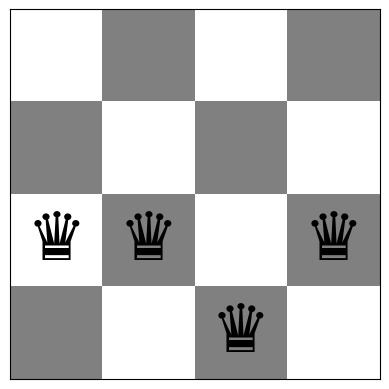

Queens (left to right) are at rows: [2 2 3 2]
Number of conflicts: 5


In [6]:
board = random_board(4)

show_board(board)
print(f"Queens (left to right) are at rows: {board}")
print(f"Number of conflicts: {conflicts(board)}")

A board $4 \times 4$ with no conflicts:

Board with 0 conflicts.


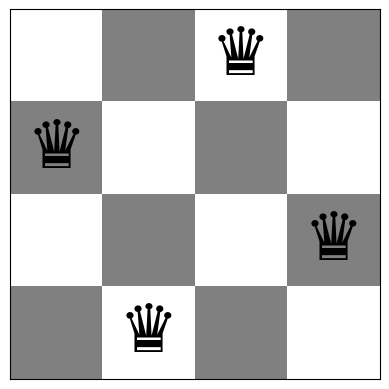

In [3]:
board = [1,3,0,2]
show_board(board)

# Tasks

## General [10 Points]

1. Make sure that you use the latest version of this notebook. Sync your forked repository and pull the latest revision.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Steepest-ascend Hill Climbing Search [20 Points]

Calculate the objective function for all local moves (see definition of local moves above) and always choose the best among all local moves. If there are no local moves that improve the objective, then you have reached a local optimum.

### Implementing task 1


In [8]:
import numpy as np

def steepest_ascent_hill_climb(n, max_steps=10_000,debug = True,debug_every=1 ):
    """
    Start from a random board.
    Repeatedly:
      - try ALL neighbors
      - move to the one with the LOWEST conflicts
    Stop when you can't improve anymore (local optimum) or max_steps reached.
    """

    board = random_board(n)
    current_c = conflicts(board)

    steps = 0

    while steps < max_steps:
        steps += 1

        best_board = board.copy()
        best_c = current_c

        # Try moving each column's queen to every other row
        for col in range(n):
            old_row = board[col]

            for row in range(n):
                if row == old_row:
                    continue  # skip "no move"

                neighbor = board.copy()
                neighbor[col] = row
                c = conflicts(neighbor)

                # keep the best (minimum conflicts)
                if c < best_c:
                    best_c = c
                    best_board = neighbor
                    best_move = (col, old_row, row)


        # Print what is happening
        if debug and (steps % debug_every == 0):
            print(f"[Step {steps}] current_conflicts={current_c}  best_conflicts={best_c}")
            if best_move is not None:
                col, oldr, newr = best_move
                print(f"   -> move queen in col={col}: row {oldr} -> {newr}")
            else:
                print("   -> no improving move found (local optimum)")


        # If no neighbor improved, we are stuck (local optimum)
        if best_c >= current_c:
            break

        # Otherwise, take the best move
        board = best_board
        current_c = best_c

        # If solved, stop early
        if current_c == 0:
            break

    return {
        "board": board,
        "conflicts": current_c,
        "steps": steps
    }

### Result veiwing finction
which can be run after each task/algoritm objective funcotion

In [9]:
def show_run_result(result, title="Result", fontsize=24):
    """
    Pass the dict returned by any hill-climb function.
    Prints summary + shows the board.
    """
    print("====", title, "====")
    print("Steps:", result.get("steps"))
    print("Conflicts:", result.get("conflicts"))
    if "patience" in result:
        print("Patience:", result["patience"])
    print("Board:", result["board"])
    show_board(result["board"], fontsize=fontsize)

Lets try to run the objective funton for the Stepest-ascend Hill Climbing

[Step 1] current_conflicts=9  best_conflicts=5
   -> move queen in col=1: row 4 -> 7
[Step 2] current_conflicts=5  best_conflicts=3
   -> move queen in col=0: row 4 -> 1
[Step 3] current_conflicts=3  best_conflicts=1
   -> move queen in col=4: row 2 -> 3
[Step 4] current_conflicts=1  best_conflicts=1
   -> move queen in col=4: row 2 -> 3
==== Task 1: Steepest-ascent ====
Steps: 4
Conflicts: 1
Board: [1 7 2 6 3 0 0 4]
Board with 1 conflicts.


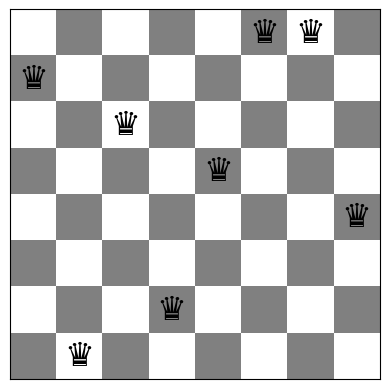

In [10]:
res = steepest_ascent_hill_climb(8)
show_run_result(res, title="Task 1: Steepest-ascent")

So As we can see form the Stepest Hiil climbing solution, we are not at the optimal solution and just getting stuck at the local optima,

## Task 2: Inefficient Stochastic Hill Climbing [10 Points]

Modify the algorithm for steepest-ascend hill climbing by choosing randomly from among all uphill moves till you have reached a local optimum.

### Implelmenting Task 2

In [15]:
def stochastic_hill_climb_inefficient(n, max_steps=10_000, debug= True, debug_every=1):
    """
    Same neighbor evaluation as steepest-ascent, but:
      - collect ALL improving moves (lower conflicts than current)
      - pick one improving move at random
    Stop if there are no improving moves (local optimum).
    """

    board = random_board(n)
    current_c = conflicts(board)

    steps = 0

    while steps < max_steps:
        steps += 1

        improving_moves = []  # store boards that improve current score so that we con select random board/step

        for col in range(n):
            old_row = board[col]
            for row in range(n):
                if row == old_row:
                    continue

                neighbor = board.copy()
                neighbor[col] = row
                c = conflicts(neighbor)

                if c < current_c:
                    improving_moves.append((neighbor, c))

        # If nothing improves us, we're stuck
        if len(improving_moves) == 0:
            break

        # Debug print
        if debug and (steps % debug_every == 0):
            print(f"[Step {steps}] current_conflicts={current_c}  improving_moves={len(improving_moves)}")

        if len(improving_moves) == 0:
            if debug:
                print("   -> no improving move found (local optimum)")
            break

        # Pick a random improving move
        idx = np.random.randint(0, len(improving_moves))
        board, current_c = improving_moves[idx]

        # solved early
        if current_c == 0:
            break

    return {
        "board": board,
        "conflicts": current_c,
        "steps": steps
    }

So now we will use the same function to show the resuults that we used earlier

[Step 1] current_conflicts=5  improving_moves=11
[Step 2] current_conflicts=4  improving_moves=6
[Step 3] current_conflicts=3  improving_moves=2
==== Task 2: Stochastic (inefficient) ====
Steps: 4
Conflicts: 2
Board: [5 0 4 1 4 6 7 2]
Board with 2 conflicts.


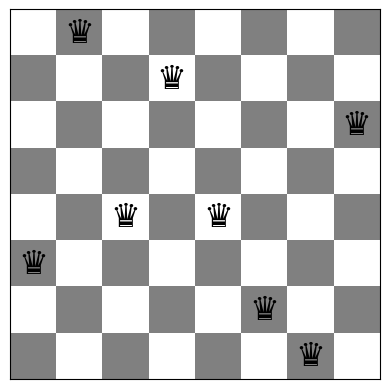

In [17]:
res2 = stochastic_hill_climb_inefficient(8, debug=True, debug_every=1)
show_run_result(res2, "Task 2: Stochastic (inefficient)")

W can see that we are still not getting the optimal solutiokn

__Important note:__ This is a very expensive algorithm since it has to calculate the objective function (number of conflicts) for all possible moves. The next algorithm produces the same result, but with much less computational cost.

## Task 3: Efficient Stochastic Hill Climbing [20 Points]

Stochastic hill climbing is in practice always implemented in the following way:

1. Generate only a single random local neighbor at a time.
2. Accept the move if it has a better objective function value than the current state.
3. Repeat till a stopping criterion is met.

This is very efficient if each state has many possible successor states. This method is called "First-choice hill climbing" in the textbook AIMA and in practice this is just called "Stochastic Hill Climbing."

__Notes:__

* Detecting local optima is tricky since you never calculate the objective function for all local moves! A popular option is to stop if you were not able to improve the objective function during the last $x$ tries. You will need to argue what the right number for $x$ is. It will depend on the size of the board. Hint: You are sampling random local moves from the set of all possible moves with replacement and you want to make sure that you trie almost all before you stop.

In [ ]:
# Code and description go here

## Task 4: Hill Climbing Search with Random Restarts [10 Points]

Hill climbing will often end up in local optima. Restart the each of the three hill climbing algorithm up to 100 times with a random board to find a better (hopefully optimal) solution. Note that restart just means to run the algorithm several times starting with a new random board.

In [ ]:
# Code and description go here

## Task 5: Simulated Annealing [10 Points]

Simulated annealing is a form of efficient stochastic hill climbing that avoid local optima by also allowing downhill moves with a probability proportional to a temperature. The temperature is decreased in every iteration following an annealing schedule. You have to experiment with the annealing schedule (Google to find guidance on this).


1. Implement simulated annealing for the n-Queens problem.
2. Create a visualization of the search process (a line chart of how the number if conflict changes as the algorithm progresses).
3. Use this visualization for experiments with different choices for the annealing schedule and discuss what you have learned.

In [ ]:
# Code and description go here

## Task 6: Algorithm Behavior Analysis [20 Points]

### Comparison
Compare the algorithm using runtime and objective function values. Use boards of size 4 and 8 to explore how the different algorithms perform. Make sure that you run the algorithms for each board size several times (at least 100 times) with different starting boards and report averages.

Complete the following table

| Algorithm            | Board size | Avg. Run time | Avg. number of conflicts | % of runs ending in optimal solution  |
| -------------------- | ---------- | ------------- | --------------------------------- | - |
| Steepest asc. HC     |     4      |               |                                   |   |
| Ineff. Stochastic HC |     4      |               |                                   |   |
| Efficient Stochastic HC |     4      |               |                                   |   |
| Simulated Annealing  |     4      |               |                                   |   |
| Steepest asc. HC     |     8      |               |                                   |   |
| Ineff. Stochastic HC |     8      |               |                                   |   |
| Efficient Stochastic HC |     8      |               |                                   |   |
| Simulated Annealing  |     8      |               |                                   |   |

Hint: See [Profiling Python Code](../HOWTOs/profiling_code.ipynb) for help about how to measure runtime in Python.

Add the used code here:

In [ ]:
# Code

### Algorithm Convergence

For each algorithm implemented, describe the typical convergence pattern (fast initial improvement vs. steady progress).
Include a plot showing the objective function value over iterations for one representative run of each algorithm on the 8-queens problem.
Explain which algorithms exhibit plateaus or getting stuck in local optima most frequently.

In [ ]:
# Code and description go here

### Problem Size Scalability

Create a log-log plot showing how runtime scales with board size ($n=4, 8, 12, 16, 20$) for at least two algorithms.
Estimate the empirical time complexity (Big O) for each algorithm based on your results.
Identify which algorithm scales best for large problem sizes and explain why.

In [ ]:
# Code and description go here

## Advanced task: Exploring other Local Moves Operators

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### Move Operator Implementation

Implement the following local move operators:

* Single-step move: Move one queen only one square up or down at a time
* Column swap: Exchange the positions of queens in two randomly selected columns
* Dual-queen move: Select two queens and move both simultaneously
* Adaptive move: Design your own operator that adapts which local move it uses based on the current state (e.g., focuses on queens with most conflicts or randomly chooses one of the moves above)

### Experimental Analysis

Using the 8-Queens and 12-Queens problems: Run your __Efficient Stochastic Hill Climbing__ implementation with each move operator 100 times.

For each operator, create a visualization showing:

* Average solution quality over iterations
* Distribution of final solution qualities
* Average time to solution for successful runs

### Discussion

Describe what you have learned from the experiments. Which operator works best for which situation and why?

In [ ]:
# Code and description go here

## More Things to Do (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment.

### Implement a Genetic Algorithm for the n-Queens problem

In [ ]:
# Code and description go here